import networkx as nx
import pandas as pd

Creating the graph:

In [43]:
edges_df = pd.read_csv("../word-graph/word_graph_edges_list.csv") 
nodes_df = pd.read_csv("../word-graph/word_graph_nodes_list.csv")   

G = nx.Graph() 

G.add_nodes_from(nodes_df['Id'])

G.add_edges_from(zip(edges_df['Source'], edges_df['Target']))

Checking if the graph is connected:

In [51]:
if nx.is_connected(G):
    print ("The graph is connected")
else:
    print ("The graph is not connected")

The graph is not connected


In [69]:
largest_cc = max(nx.connected_components(G), key=len)
G_sub = G.subgraph(largest_cc)
diameter = nx.diameter(G_sub)
print("Graph's biggest component diameter:", diameter)

Graph's biggest component diameter: 7


In [83]:
density = nx.density(G)
print("Graph's density", density)

Graph's density 0.0021199350055854573


In [87]:
bridges = list(nx.bridges(G))

print("Number of bridges:", len(bridges))
print("Bridges:", bridges)

Number of bridges: 51
Bridges: [('good', 'wish'), ('good', 'reason'), ('way', 'step'), ('baby', 'blame'), ('baby', 'believe'), ('baby', 'young'), ('love', 'real'), ('love', 'trust'), ('love', 'keep'), ('love', 'pain'), ('love', 'big'), ('love', 'see'), ('think', 'hear'), ('feel', 'air'), ('night', 'thinkin'), ('night', 'remember'), ('little', 'pretty'), ('time', 'waste'), ('time', 'cold'), ('time', 'pass'), ('bitch', 'foot'), ('bitch', 'talk'), ('bitch', 'fuckin'), ('day', 'die'), ('away', 'watch'), ('girl', 'fun'), ('say', 'block'), ('help', 'act'), ('well', 'forever'), ('well', 'late'), ('dance', 'floor'), ('burn', 'smoke'), ('door', 'open'), ('stop', 'crash'), ('stop', 'beat'), ('road', 'high'), ('man', 'city'), ('okay', 'place'), ('whiskey', 'shot'), ('bed', 'wake'), ('tired', 'wonder'), ('bar', 'street'), ('low', 'high'), ('round', 'damn'), ('round', 'stick'), ('damn', 'pour'), ('pour', 'drink'), ('forget', 'daddy'), ('red', 'wine'), ('fast', 'car'), ('car', 'drive')]


In [91]:
articulation_points = list(nx.articulation_points(G))

print("Number of articulation points:", len(articulation_points))
print("Articulation points:", articulation_points)

Number of articulation points: 33
Articulation points: ['bed', 'dance', 'away', 'good', 'feel', 'burn', 'okay', 'girl', 'little', 'tired', 'whiskey', 'bar', 'man', 'door', 'help', 'night', 'high', 'road', 'way', 'time', 'well', 'say', 'bitch', 'stop', 'day', 'love', 'think', 'baby', 'thing', 'pour', 'damn', 'round', 'car']


In [99]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

In [97]:
print("Top 5 by degree centrality:", sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5])
print("Top 5 by betweenness centrality:", sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5])
print("Top 5 by closeness centrality:", sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:5])

Top 5 by degree centrality: [('love', 0.09315866084425037), ('baby', 0.06841339155749636), ('think', 0.048034934497816595), ('good', 0.042212518195050945), ('night', 0.03784570596797671)]
Top 5 by betweenness centrality: [('love', 0.021763468043880633), ('baby', 0.012463308316188564), ('good', 0.0080385995478823), ('way', 0.0047544374149642195), ('bitch', 0.004620209072185368)]
Top 5 by closeness centrality: [('love', 0.14689956331877727), ('baby', 0.13274056926395536), ('think', 0.12173996960119664), ('say', 0.12008138690908225), ('good', 0.11943053928355876)]


In [113]:
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity
import itertools

In [115]:
k=1
comp = girvan_newman(G)
for communities in itertools.islice(comp, k):
    print(tuple(sorted(c) for c in communities))

([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])


In [117]:
nx.community.modularity(G, communities)

0.3476602762317048

In [119]:
k=2
comp = girvan_newman(G)
for communities in itertools.islice(comp, k):
    print(tuple(sorted(c) for c in communities))

([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])
([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [9])


In [121]:
nx.community.modularity(G, communities)

0.3423192968647514

In [123]:
k=3
comp = girvan_newman(G)
for communities in itertools.islice(comp, k):
    print(tuple(sorted(c) for c in communities))

([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])
([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [9])
([0, 1, 3, 7, 11, 12, 13, 17, 19, 21], [2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [4, 5, 6, 10, 16], [9])


In [125]:
nx.community.modularity(G, communities)

0.3580611307884035

In [127]:
k=4
comp = girvan_newman(G)
for communities in itertools.islice(comp, k):
    print(tuple(sorted(c) for c in communities))

([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])
([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [9])
([0, 1, 3, 7, 11, 12, 13, 17, 19, 21], [2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [4, 5, 6, 10, 16], [9])
([0, 1, 3, 7, 11, 12, 13, 17, 19, 21], [2, 24, 25, 27, 28, 31], [4, 5, 6, 10, 16], [8, 14, 15, 18, 20, 22, 23, 26, 29, 30, 32, 33], [9])


In [129]:
nx.community.modularity(G, communities)

0.3849721706864564

In [131]:
k=5
comp = girvan_newman(G)
for communities in itertools.islice(comp, k):
    print(tuple(sorted(c) for c in communities))

([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])
([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [9])
([0, 1, 3, 7, 11, 12, 13, 17, 19, 21], [2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [4, 5, 6, 10, 16], [9])
([0, 1, 3, 7, 11, 12, 13, 17, 19, 21], [2, 24, 25, 27, 28, 31], [4, 5, 6, 10, 16], [8, 14, 15, 18, 20, 22, 23, 26, 29, 30, 32, 33], [9])
([0, 1, 3, 7, 12, 13, 17, 19, 21], [2, 24, 25, 27, 28, 31], [4, 5, 6, 10, 16], [8, 14, 15, 18, 20, 22, 23, 26, 29, 30, 32, 33], [9], [11])


In [133]:
nx.community.modularity(G, communities)

0.3757800640917524

In [147]:
k = 4
comp = girvan_newman(G)
for communities in itertools.islice(comp, k):
    print(tuple(sorted(c) for c in communities))

communities

([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])
([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [9])
([0, 1, 3, 7, 11, 12, 13, 17, 19, 21], [2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [4, 5, 6, 10, 16], [9])
([0, 1, 3, 7, 11, 12, 13, 17, 19, 21], [2, 24, 25, 27, 28, 31], [4, 5, 6, 10, 16], [8, 14, 15, 18, 20, 22, 23, 26, 29, 30, 32, 33], [9])


({0, 1, 3, 7, 11, 12, 13, 17, 19, 21},
 {2, 24, 25, 27, 28, 31},
 {4, 5, 6, 10, 16},
 {8, 14, 15, 18, 20, 22, 23, 26, 29, 30, 32, 33},
 {9})

NameError: name 'node_groups' is not defined

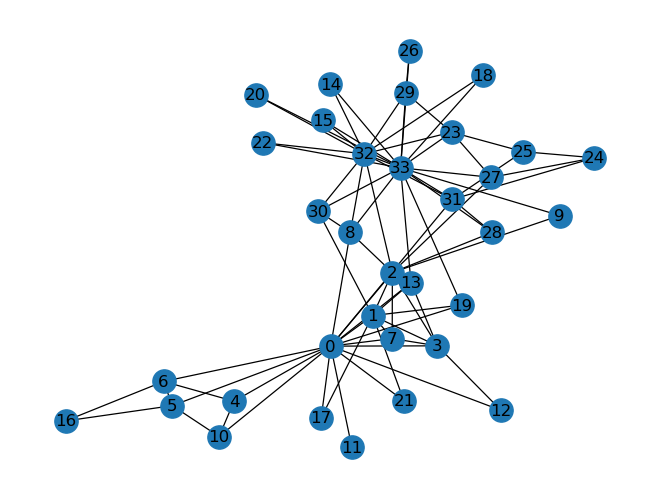

In [149]:
pos = nx.spring_layout(G)
nx.draw(G, pos=pos, edge_color='k',  with_labels=True,
         node_size=280, font_weight='light', width= 0.9)

#For each community list, draw the nodes, giving it a specific color.
nx.draw_networkx_nodes(G, pos=pos, nodelist=node_groups[0], node_color='b')
nx.draw_networkx_nodes(G, pos=pos, nodelist=node_groups[1], node_color='r')
nx.draw_networkx_nodes(G, pos=pos, nodelist=node_groups[2], node_color='g')